In [1]:
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/home/svu/e1498138/emri_search/work/'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_timemax_noise import LogLike
# from loglike_phasemax_noise import LogLike
import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 5
T = 3/12
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 4.5
qS = np.pi
phiS = 0.
qK = 0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')

data_snr = float(gwf.rhostat_timemax(loglike_obj.signal).get())
print(f'SNR (time-max): {data_snr:.4f}')

print("Setting up log_density and prior functions...")

def log_density(params):
    params = np.asarray(params)
    log_likes = np.zeros(params.shape[0])
    for i in range(params.shape[0]):
        logm1, logm2, a, p0, e0 = params[i]
        try:
            loglike = loglike_obj(np.array([
                10**logm1, 10**logm2, a, p0, e0,
                xI0, dist, qS, phiS, qK, phiK,
                Phi_phi0, Phi_theta0, Phi_r0
            ])) 
        except Exception:
            loglike = -np.inf
        log_likes[i] = loglike
    return log_likes


def prior_transform(u):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]
    t = np.zeros_like(u)
    t[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]
    t[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]
    t[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    t[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]
    t[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    return t


def inverse_prior_transform(params):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]
    params = np.asarray(params)
    u = np.zeros_like(params)
    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    return u


Using dt=5s, T=0.25yr, TDI gen=1
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
LogLike initialized.
SNR (time-max): 2175.8140
Setting up log_density and prior functions...


In [ ]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paris2_noise/int_3mth_new_7'


In [ ]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl')

In [ ]:
samples, weights = sampler.get_samples_with_weights(flatten=True)

In [ ]:
proc_pt = sampler.searched_points_list
proc_pt

[array([[ 0.64787778,  0.37126272,  0.813048  ,  0.16950002,  0.73023347],
        [ 0.92711813,  2.11024916,  0.86884914, -0.07532176,  4.56970867],
        [ 1.24367357, -0.67411589, -1.22110564, -2.94385789,  0.7544699 ],
        ...,
        [ 0.59049863,  0.51263832,  0.63882658,  0.56845866,  0.89516008],
        [ 0.58052544, -0.02252212,  0.48743303,  0.46838635,  0.83157112],
        [ 1.04852154,  1.76598048,  0.40716971,  0.48608255,  0.96371102]])]

In [ ]:
logden_list = sampler.searched_log_densities_list
logden_list

[array([49.7442295 ,        -inf,        -inf, ..., 35.06233949,
               -inf,        -inf])]

In [ ]:
sampler.now_covariances

[array([[ 0.01048128,  0.02165134, -0.00794028, -0.00671503,  0.00166186],
        [ 0.02165134,  0.22736199,  0.01080469,  0.06334274,  0.00932026],
        [-0.00794028,  0.01080469,  0.02220161,  0.01618003, -0.00148232],
        [-0.00671503,  0.06334274,  0.01618003,  0.04200395,  0.00131031],
        [ 0.00166186,  0.00932026, -0.00148232,  0.00131031,  0.00452214]])]

In [ ]:
np.argmax(logden_list)

80824

In [ ]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[6.18778169, 1.07852362, 0.48733179, 9.35849301, 0.44690793]])

In [10]:
log_density(maxld_pt1)

array([5.6974819])

In [11]:
log_density([param_true])

array([9.92879914])

In [ ]:
param_ranges = [(5.6,6.4),
                (0.8,1.3),
                (0.3,0.99),
                (8.0,11.0),
                (0.2,0.5),
                ]
param_ranges

[(5.6, 6.4), (0.8, 1.3), (0.3, 0.99), (8.0, 11.0), (0.2, 0.5)]

In [ ]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]
param_true

[6.0, 1.0, 0.7, 9, 0.4]

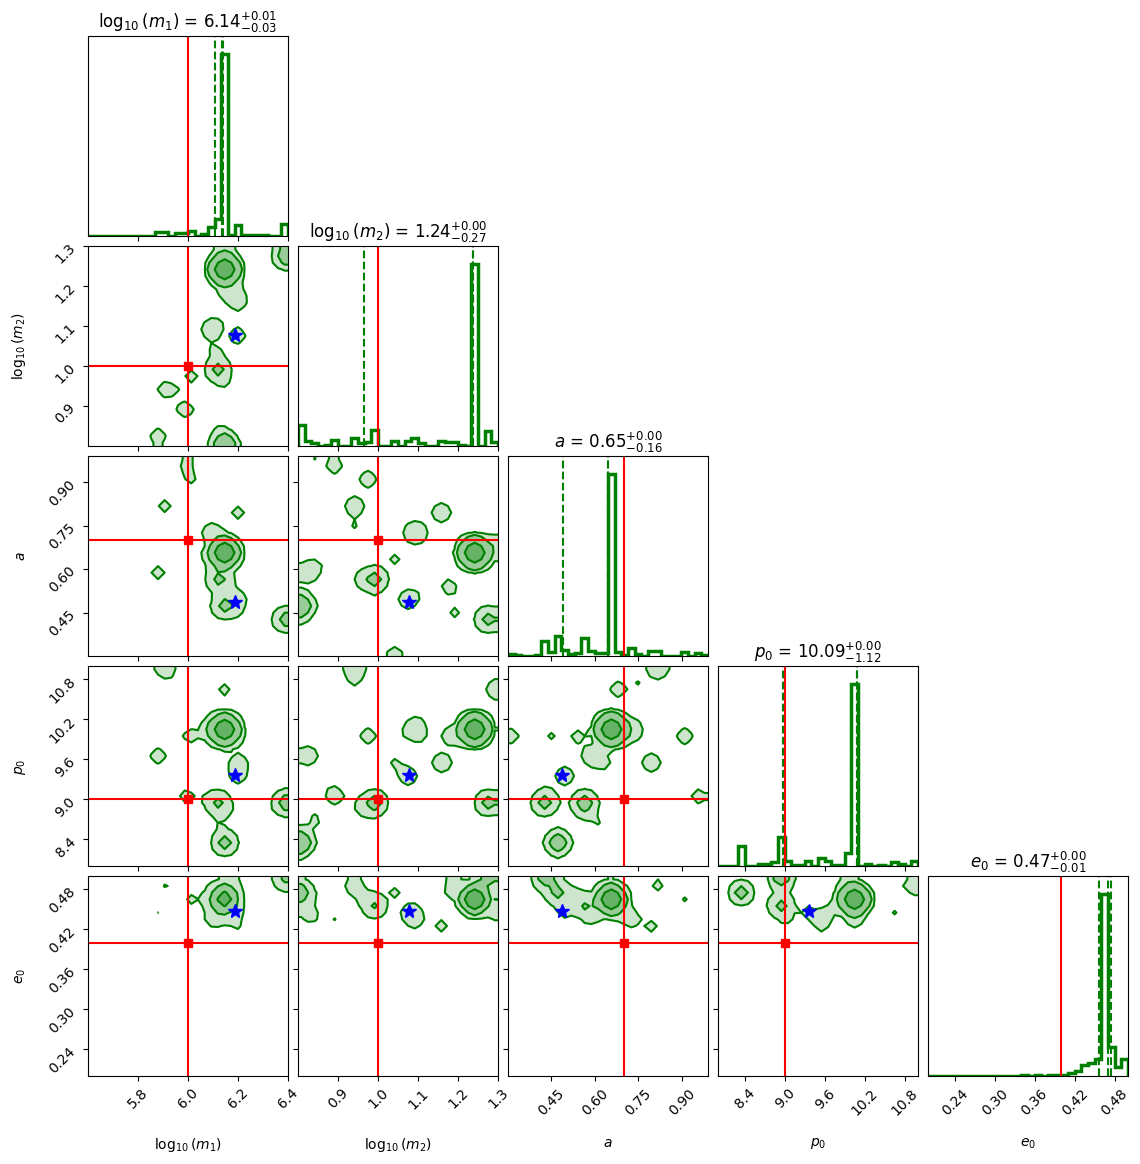

In [ ]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$',r'$T$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)




In [ ]:
w_norm = weights / weights.sum()
ess = 1.0 / np.sum(w_norm**2)
print(f"ESS: {ess:.1f}  ({100*ess/len(weights):.2f}% of N={len(weights)})")

ESS: 2.7  (0.00% of N=100000)


# connection plot

In [22]:
from scipy.stats import chi2

# --- Mahalanobis distance: does this run's posterior ellipsoid contain the truth? ---
w_norm_mh = weights / weights.sum()

rng_mh = np.random.default_rng(0)
idx_mh = rng_mh.choice(len(samples), size=50_000, replace=True, p=w_norm_mh)
cov_posterior = np.cov(samples[idx_mh].T)

mu_center = maxld_pt1[0]
true_pt   = np.array(param_true)

mu_center = maxld_pt1[0]
true_pt   = np.array(param_true)
delta     = true_pt - mu_center

maha = np.sqrt(delta @ np.linalg.inv(cov_posterior) @ delta)
k    = len(mu_center)
covered_frac = chi2.cdf(maha**2, df=k)   # posterior-mass fraction enclosed by an ellipsoid this size

print(f"mu_center (max-logden pt): {mu_center}")
print(f"param_true:                {true_pt}")
print(f"delta (true - mu_center):  {delta}")
print()
print(f"Mahalanobis distance of truth from mu_center: {maha:.3f}")
print(f"Equivalent enclosed posterior-mass fraction:   {covered_frac:.6f}")
print(f"  -> need an ellipsoid of Mahalanobis radius >= {maha:.2f} to contain the truth")
for n_sigma in [1, 2, 3, 6, 10]:
    print(f"  r={n_sigma:>2} ellipsoid: truth {'INSIDE' if maha <= n_sigma else 'OUTSIDE'}")

mu_center (max-logden pt): [6.18778169 1.07852362 0.48733179 9.35849301 0.44690793]
param_true:                [6.  1.  0.7 9.  0.4]
delta (true - mu_center):  [-0.18778169 -0.07852362  0.21266821 -0.35849301 -0.04690793]

Mahalanobis distance of truth from mu_center: 6.163
Equivalent enclosed posterior-mass fraction:   1.000000
  -> need an ellipsoid of Mahalanobis radius >= 6.16 to contain the truth
  r= 1 ellipsoid: truth OUTSIDE
  r= 2 ellipsoid: truth OUTSIDE
  r= 3 ellipsoid: truth OUTSIDE
  r= 6 ellipsoid: truth OUTSIDE
  r=10 ellipsoid: truth INSIDE


In [16]:
proc1_maxld_pt = maxld_pt1.copy()
proc1_maxld_pt

array([[6.18778169, 1.07852362, 0.48733179, 9.35849301, 0.44690793]])

In [17]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [18]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [19]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


In [20]:
logden_theory_proc1

array([5.6974819 , 3.02016818, 2.77946689, 3.15647039, 4.18533385,
       4.6645515 , 4.79072804, 4.04213665, 4.1202172 , 3.79069989,
       4.71716602, 3.52799206, 3.68781473, 4.24295382, 4.07829131,
       2.83892554, 3.59155653, 3.31490074, 3.37295154, 3.22342517,
       3.32413119, 4.12793543, 3.18266821, 3.28240798, 3.665005  ,
       3.35161134, 2.4559125 , 3.2876189 , 2.98161973, 3.23152235,
       3.50831198, 3.37645998, 2.74152062, 3.30354406, 2.78571625,
       3.27238174, 3.86851788, 2.56673402, 2.77502175, 2.57209617,
       2.95906694, 2.26315999, 2.53951315, 2.19924388, 3.23781324,
       2.40921025, 2.18015187, 2.47825733, 1.80432504, 9.92879914])

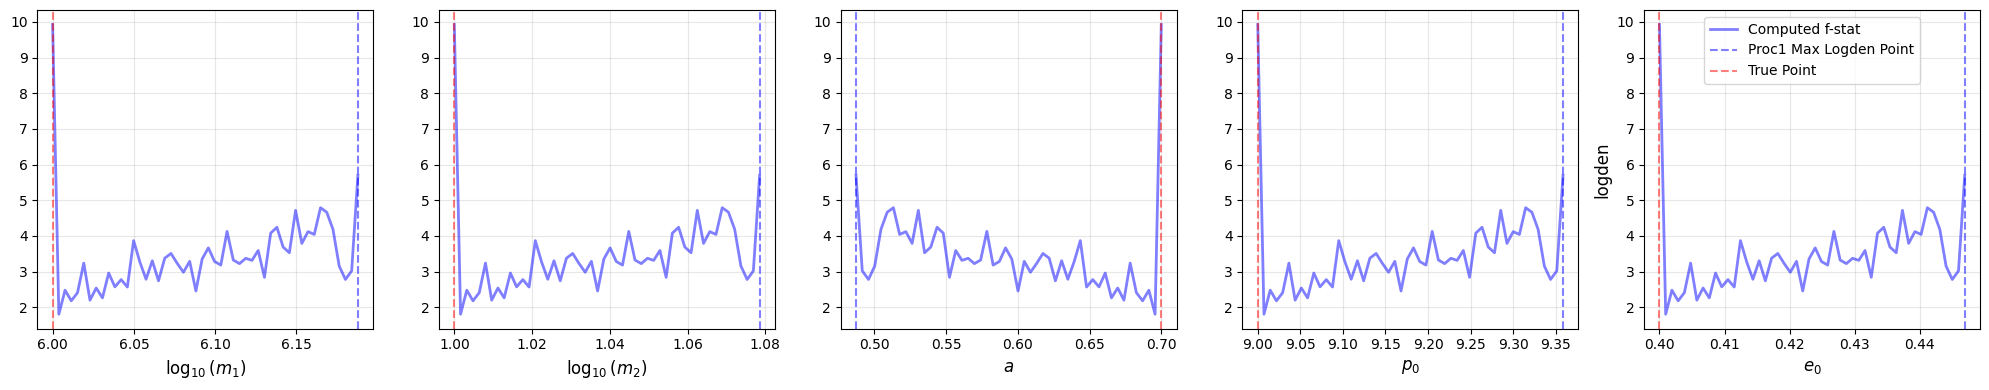

In [21]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$T$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()
